# Análisis Exploratorio de Datos (EDA)
# Barcelona Housing & Demographics

**Autor:** Barcelona Housing Analytics Team  
**Fecha:** 28 de diciembre de 2024  
**Objetivo:** Análisis exploratorio completo del mercado inmobiliario de Barcelona

---

## Contenido

1. [Configuración y Carga de Datos](#1-configuracion)
2. [Calidad de Datos](#2-calidad)
3. [Análisis de Precios](#3-precios)
4. [Análisis de Renta e Inequidad](#4-renta)
5. [Análisis de Hogares](#5-hogares)
6. [Análisis de Catastro](#6-catastro)
7. [Análisis Integrado](#7-integrado)
8. [Conclusiones](#8-conclusiones)

## 1. Configuración y Carga de Datos <a name="1-configuracion"></a>

In [16]:
# Imports
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [17]:
# Conectar a la base de datos
db_path = Path("../data/master.db")
conn = sqlite3.connect(db_path)

print(f"✅ Conectado a: {db_path}")
print(f"   Tamaño: {db_path.stat().st_size / 1024 / 1024:.2f} MB")

✅ Conectado a: ../data/master.db
   Tamaño: 2.84 MB


In [18]:
# Listar tablas disponibles
tables = pd.read_sql("""
    SELECT name, type 
    FROM sqlite_master 
    WHERE type='table' 
    ORDER BY name
""", conn)

print(f"📊 Tablas disponibles: {len(tables)}\n")
display(tables)

📊 Tablas disponibles: 30



,name,type
0,dim_barrios,table
1,dim_barrios_extended,table
2,dim_tiempo,table
3,etl_runs,table
4,fact_calidad_aire,table
5,fact_catastro_avanzado,table
6,fact_comercio,table
7,fact_demografia,table
8,fact_demografia_ampliada,table
9,fact_desempleo,table


In [19]:
import sqlite3
import pandas as pd
from pathlib import Path

# Configurar ruta a la base de datos
# (Asumiendo que estás dentro de la carpeta /notebooks)
db_path = Path("../data/master.db")

try:
    conn = sqlite3.connect(db_path)
    print("✅ Conexión establecida")
    
    # Cargar los datos
    fact_precios = pd.read_sql("SELECT * FROM fact_precios", conn)
    fact_renta_avanzada = pd.read_sql("SELECT * FROM fact_renta_avanzada", conn)
    fact_hogares_avanzado = pd.read_sql("SELECT * FROM fact_hogares_avanzado", conn)
    fact_catastro_avanzado = pd.read_sql("SELECT * FROM fact_catastro_avanzado", conn)
    dim_barrios = pd.read_sql("SELECT * FROM dim_barrios", conn)
    
    print("✅ Todas las variables han sido cargadas en memoria")
    print(f"📊 fact_renta_avanzada tiene {len(fact_renta_avanzada)} filas")

except Exception as e:
    print(f"❌ Error al cargar los datos: {e}")
    print(f"Verifica que el archivo exista en: {db_path.absolute()}")

✅ Conexión establecida
✅ Todas las variables han sido cargadas en memoria
📊 fact_renta_avanzada tiene 292 filas


In [20]:
# Cargar dimensiones
dim_barrios = pd.read_sql("SELECT * FROM dim_barrios", conn)
dim_tiempo = pd.read_sql("SELECT * FROM dim_tiempo", conn)

print(f"📍 Barrios: {len(dim_barrios)}")
print(f"📅 Años: {dim_tiempo['anio'].min()} - {dim_tiempo['anio'].max()}")

# Cargar datos de hechos
fact_precios = pd.read_sql("SELECT * FROM fact_precios", conn)
fact_renta_avanzada = pd.read_sql("SELECT * FROM fact_renta_avanzada", conn)
fact_hogares_avanzado = pd.read_sql("SELECT * FROM fact_hogares_avanzado", conn)
fact_catastro_avanzado = pd.read_sql("SELECT * FROM fact_catastro_avanzado", conn)

print(f"\n💰 Precios: {len(fact_precios):,} registros")
print(f"💵 Renta: {len(fact_renta_avanzada):,} registros")
print(f"🏠 Hogares: {len(fact_hogares_avanzado):,} registros")
print(f"🏛️ Catastro: {len(fact_catastro_avanzado):,} registros")

📍 Barrios: 73
📅 Años: 2015 - 2024

💰 Precios: 6,358 registros
💵 Renta: 292 registros
🏠 Hogares: 365 registros
🏛️ Catastro: 365 registros


## 2. Calidad de Datos <a name="2-calidad"></a>

In [21]:
# Función para analizar calidad de datos
def data_quality_report(df, name):
    print(f"\n{'='*80}")
    print(f"CALIDAD DE DATOS: {name}")
    print(f"{'='*80}")
    
    print(f"\nDimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    
    # Valores nulos
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df) * 100).round(2)
    
    null_df = pd.DataFrame({
        'Columna': null_counts.index,
        'Nulos': null_counts.values,
        '% Nulos': null_pct.values
    })
    
    null_df = null_df[null_df['Nulos'] > 0].sort_values('% Nulos', ascending=False)
    
    if len(null_df) > 0:
        print(f"\n⚠️ Columnas con valores nulos:")
        display(null_df)
    else:
        print("\n✅ Sin valores nulos")
    
    # Tipos de datos
    print(f"\nTipos de datos:")
    print(df.dtypes.value_counts())
    
    return null_df

# Analizar cada dataset
quality_precios = data_quality_report(fact_precios, "PRECIOS")
quality_renta = data_quality_report(fact_renta_avanzada, "RENTA")
quality_hogares = data_quality_report(fact_hogares_avanzado, "HOGARES")
quality_catastro = data_quality_report(fact_catastro_avanzado, "CATASTRO")


CALIDAD DE DATOS: PRECIOS

Dimensiones: 6,358 filas × 10 columnas

⚠️ Columnas con valores nulos:


,Columna,Nulos,% Nulos
4,trimestre,6358,100.00
6,precio_mes_alquiler,5492,86.38
5,precio_m2_venta,866,13.62



Tipos de datos:
object     5
int64      3
float64    2
Name: count, dtype: int64

CALIDAD DE DATOS: RENTA

Dimensiones: 292 filas × 9 columnas

⚠️ Columnas con valores nulos:


,Columna,Nulos,% Nulos
6,dataset_id,292,100.00



Tipos de datos:
int64      3
float64    3
object     3
Name: count, dtype: int64

CALIDAD DE DATOS: HOGARES

Dimensiones: 365 filas × 11 columnas

⚠️ Columnas con valores nulos:


,Columna,Nulos,% Nulos
4,pct_hogares_unipersonales,365,100.00
8,dataset_id,365,100.00



Tipos de datos:
int64      4
object     4
float64    3
Name: count, dtype: int64

CALIDAD DE DATOS: CATASTRO

Dimensiones: 365 filas × 12 columnas

⚠️ Columnas con valores nulos:


,Columna,Nulos,% Nulos
7,num_plantas_avg,365,100.00
9,dataset_id,365,100.00
3,num_propietarios_fisica,73,20.00
4,num_propietarios_juridica,73,20.00
6,superficie_media_m2,73,20.00



Tipos de datos:
float64    5
object     4
int64      3
Name: count, dtype: int64


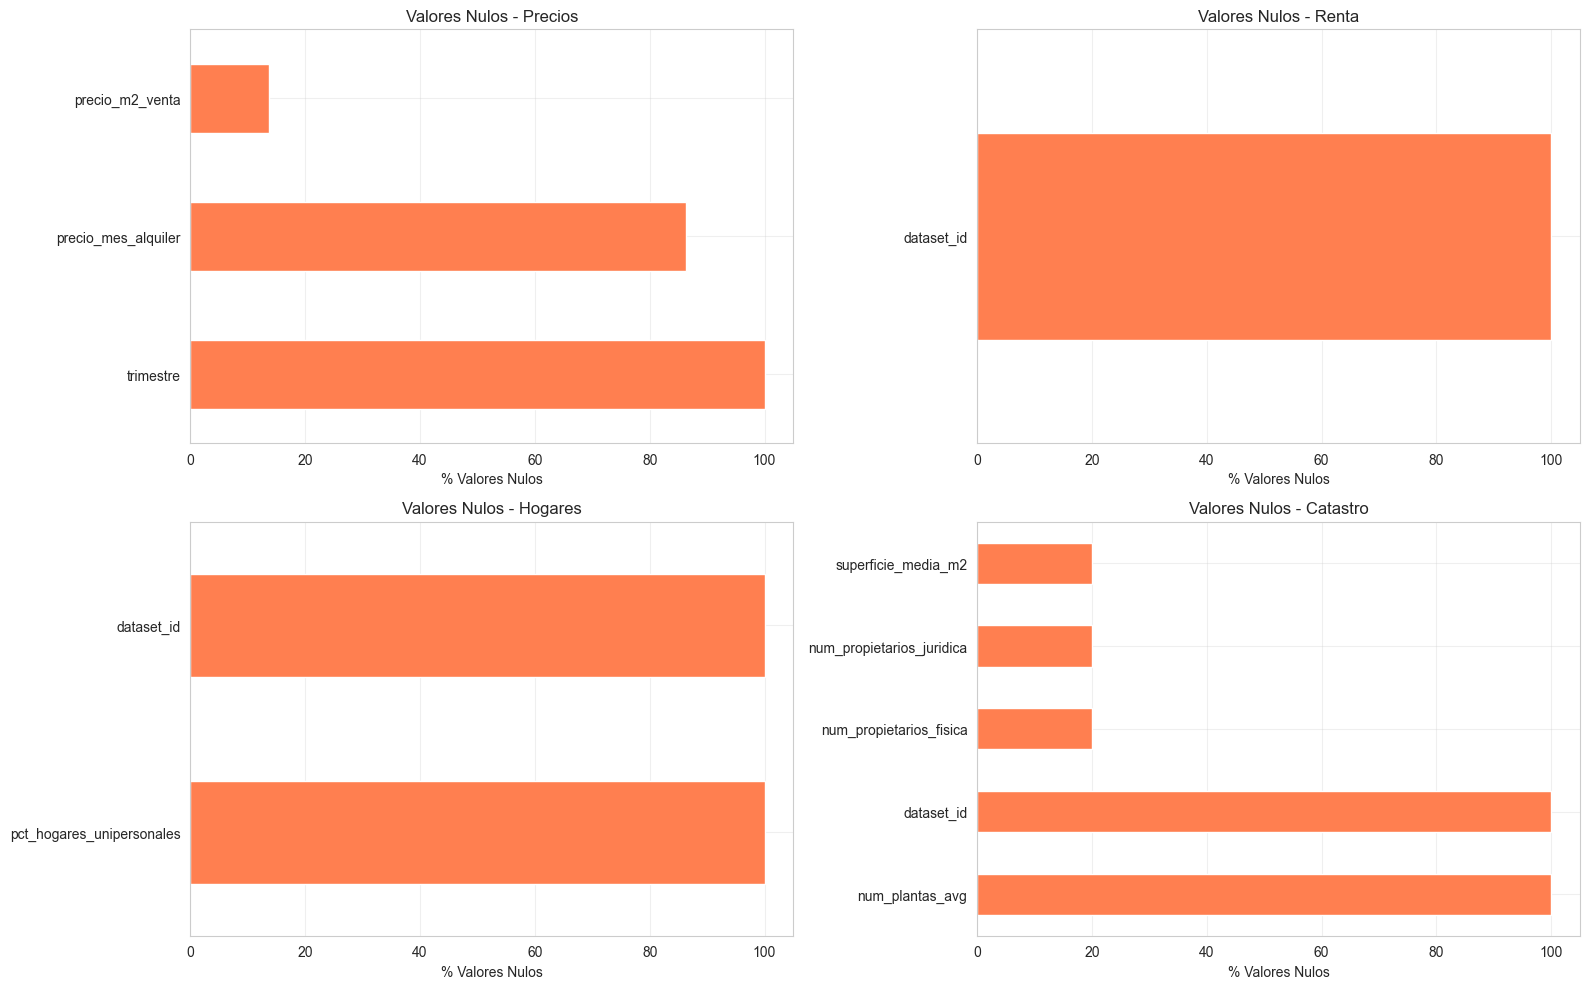

In [22]:
# Visualizar valores nulos
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

datasets = [
    (fact_precios, "Precios", axes[0, 0]),
    (fact_renta_avanzada, "Renta", axes[0, 1]),
    (fact_hogares_avanzado, "Hogares", axes[1, 0]),
    (fact_catastro_avanzado, "Catastro", axes[1, 1])
]

for df, name, ax in datasets:
    null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]
    
    if len(null_pct) > 0:
        null_pct.plot(kind='barh', ax=ax, color='coral')
        ax.set_xlabel('% Valores Nulos')
        ax.set_title(f'Valores Nulos - {name}')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Sin valores nulos', 
                ha='center', va='center', fontsize=14)
        ax.set_title(f'Valores Nulos - {name}')

plt.tight_layout()
plt.savefig('../reports/eda_calidad_datos.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Análisis de Precios <a name="3-precios"></a>

In [23]:
# Estadísticas descriptivas de precios
print("PRECIOS DE VENTA (€/m²)")
print("="*50)
display(fact_precios['precio_m2_venta'].describe())

print("\nPRECIOS DE ALQUILER (€/mes)")
print("="*50)
display(fact_precios['precio_mes_alquiler'].describe())

PRECIOS DE VENTA (€/m²)


count    5492.00
mean     3161.49
std      1279.90
min       342.61
25%      2187.58
50%      2991.45
75%      3993.53
max     12154.22
Name: precio_m2_venta, dtype: float64


PRECIOS DE ALQUILER (€/mes)


count    866.00
mean     860.39
std      287.76
min      211.35
25%      667.70
50%      815.84
75%      994.35
max     2088.15
Name: precio_mes_alquiler, dtype: float64

In [24]:
# Test de normalidad
venta_data = fact_precios['precio_m2_venta'].dropna()
alquiler_data = fact_precios['precio_mes_alquiler'].dropna()

# Muestra para test
venta_sample = venta_data.sample(min(5000, len(venta_data)), random_state=42)
alquiler_sample = alquiler_data.sample(min(5000, len(alquiler_data)), random_state=42)

# Shapiro-Wilk test
shapiro_venta = stats.shapiro(venta_sample)
shapiro_alquiler = stats.shapiro(alquiler_sample)

# Test en escala log
shapiro_log_venta = stats.shapiro(np.log(venta_sample))
shapiro_log_alquiler = stats.shapiro(np.log(alquiler_sample))

print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("="*50)
print(f"\nPRECIOS DE VENTA:")
print(f"  Escala normal: W={shapiro_venta.statistic:.4f}, p={shapiro_venta.pvalue:.4e}")
print(f"  Escala log:    W={shapiro_log_venta.statistic:.4f}, p={shapiro_log_venta.pvalue:.4e}")
print(f"  Conclusión: {'✓ LOG-NORMAL' if shapiro_log_venta.pvalue > shapiro_venta.pvalue else '✗ No log-normal'}")

print(f"\nPRECIOS DE ALQUILER:")
print(f"  Escala normal: W={shapiro_alquiler.statistic:.4f}, p={shapiro_alquiler.pvalue:.4e}")
print(f"  Escala log:    W={shapiro_log_alquiler.statistic:.4f}, p={shapiro_log_alquiler.pvalue:.4e}")
print(f"  Conclusión: {'✓ LOG-NORMAL' if shapiro_log_alquiler.pvalue > shapiro_alquiler.pvalue else '✗ No log-normal'}")

TEST DE NORMALIDAD (Shapiro-Wilk)

PRECIOS DE VENTA:
  Escala normal: W=0.9708, p=9.6847e-31
  Escala log:    W=0.9852, p=1.8405e-22
  Conclusión: ✓ LOG-NORMAL

PRECIOS DE ALQUILER:
  Escala normal: W=0.9466, p=3.8351e-17
  Escala log:    W=0.9892, p=5.4339e-06
  Conclusión: ✓ LOG-NORMAL


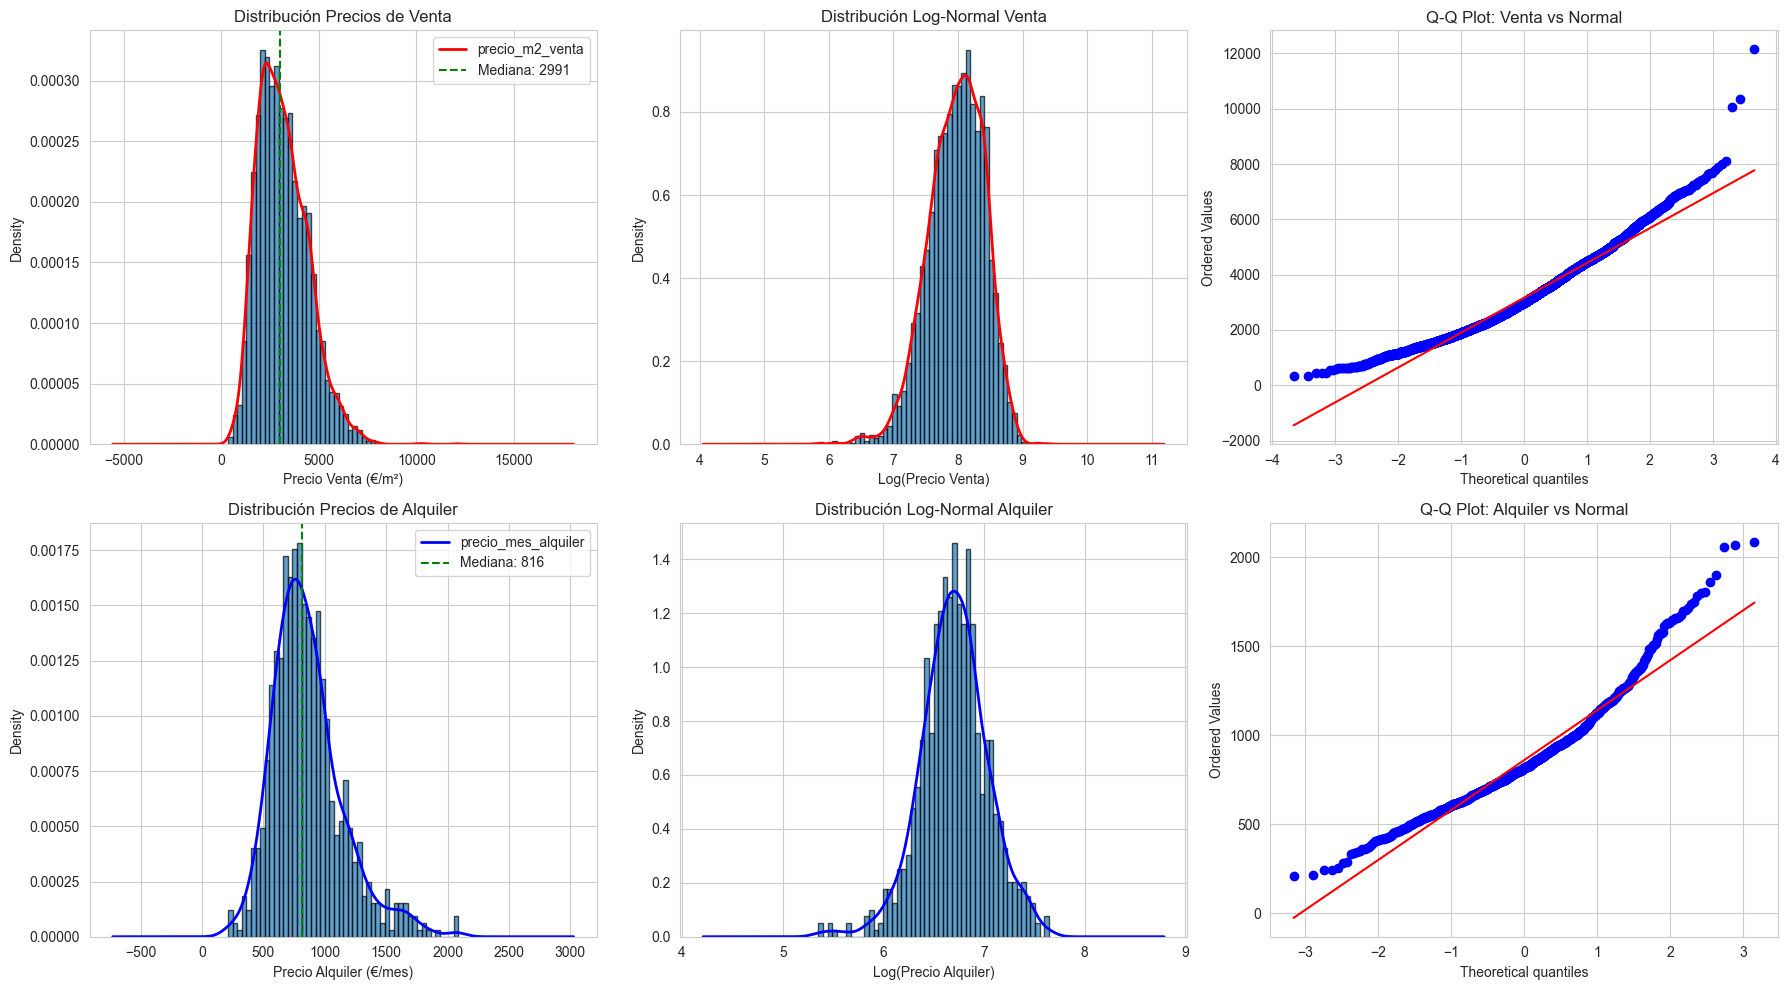

In [25]:
# Visualización de distribuciones
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Venta - Histograma
axes[0, 0].hist(venta_data, bins=50, edgecolor='black', alpha=0.7, density=True)
venta_data.plot(kind='kde', ax=axes[0, 0], color='red', linewidth=2)
axes[0, 0].set_xlabel('Precio Venta (€/m²)')
axes[0, 0].set_title('Distribución Precios de Venta')
axes[0, 0].axvline(venta_data.median(), color='green', linestyle='--', 
                   label=f'Mediana: {venta_data.median():.0f}')
axes[0, 0].legend()

# Venta - Log
axes[0, 1].hist(np.log(venta_data), bins=50, edgecolor='black', alpha=0.7, density=True)
pd.Series(np.log(venta_data)).plot(kind='kde', ax=axes[0, 1], color='red', linewidth=2)
axes[0, 1].set_xlabel('Log(Precio Venta)')
axes[0, 1].set_title('Distribución Log-Normal Venta')

# Venta - Q-Q Plot
stats.probplot(venta_data, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot: Venta vs Normal')

# Alquiler - Histograma
axes[1, 0].hist(alquiler_data, bins=50, edgecolor='black', alpha=0.7, density=True)
alquiler_data.plot(kind='kde', ax=axes[1, 0], color='blue', linewidth=2)
axes[1, 0].set_xlabel('Precio Alquiler (€/mes)')
axes[1, 0].set_title('Distribución Precios de Alquiler')
axes[1, 0].axvline(alquiler_data.median(), color='green', linestyle='--',
                   label=f'Mediana: {alquiler_data.median():.0f}')
axes[1, 0].legend()

# Alquiler - Log
axes[1, 1].hist(np.log(alquiler_data), bins=50, edgecolor='black', alpha=0.7, density=True)
pd.Series(np.log(alquiler_data)).plot(kind='kde', ax=axes[1, 1], color='blue', linewidth=2)
axes[1, 1].set_xlabel('Log(Precio Alquiler)')
axes[1, 1].set_title('Distribución Log-Normal Alquiler')

# Alquiler - Q-Q Plot
stats.probplot(alquiler_data, dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Q-Q Plot: Alquiler vs Normal')

plt.tight_layout()
plt.savefig('../reports/eda_distribucion_precios.png', dpi=300, bbox_inches='tight')
plt.show()

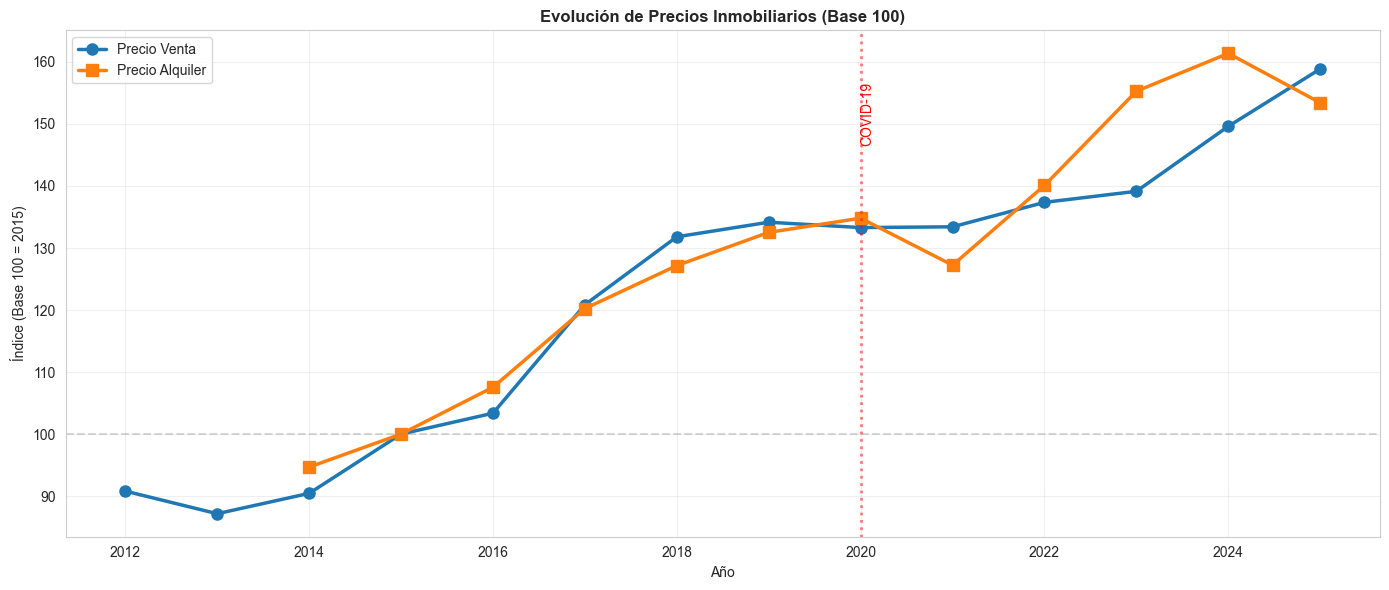

,anio,precio_m2_venta,precio_mes_alquiler,index_venta,index_alquiler
0,2012,2317.57,NaN,90.81,NaN
1,2013,2224.52,NaN,87.16,NaN
2,2014,2308.20,629.52,90.44,94.67
3,2015,2552.20,664.95,100.00,100.00
4,2016,2638.03,715.14,103.36,107.55
5,2017,3084.35,799.50,120.85,120.23
6,2018,3363.94,845.61,131.81,127.17
7,2019,3423.96,881.22,134.16,132.52
8,2020,3401.94,896.42,133.29,134.81
9,2021,3405.03,846.05,133.42,127.23


In [26]:
# Evolución temporal
yearly_prices = fact_precios.groupby('anio').agg({
    'precio_m2_venta': 'mean',
    'precio_mes_alquiler': 'mean'
}).reset_index()

# Indexar a base 100 (2015)
base_year = 2015
if base_year in yearly_prices['anio'].values:
    base_venta = yearly_prices[yearly_prices['anio'] == base_year]['precio_m2_venta'].values[0]
    base_alquiler = yearly_prices[yearly_prices['anio'] == base_year]['precio_mes_alquiler'].values[0]
else:
    base_venta = yearly_prices['precio_m2_venta'].iloc[0]
    base_alquiler = yearly_prices['precio_mes_alquiler'].iloc[0]

yearly_prices['index_venta'] = (yearly_prices['precio_m2_venta'] / base_venta) * 100
yearly_prices['index_alquiler'] = (yearly_prices['precio_mes_alquiler'] / base_alquiler) * 100

# Visualizar
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(yearly_prices['anio'], yearly_prices['index_venta'], 
        marker='o', linewidth=2.5, label='Precio Venta', markersize=8)
ax.plot(yearly_prices['anio'], yearly_prices['index_alquiler'], 
        marker='s', linewidth=2.5, label='Precio Alquiler', markersize=8)

ax.axvline(x=2020, color='red', linestyle=':', alpha=0.5, linewidth=2)
ax.text(2020, ax.get_ylim()[1]*0.95, 'COVID-19', rotation=90, 
        verticalalignment='top', color='red')

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Año')
ax.set_ylabel('Índice (Base 100 = 2015)')
ax.set_title('Evolución de Precios Inmobiliarios (Base 100)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/eda_evolucion_precios.png', dpi=300, bbox_inches='tight')
plt.show()

display(yearly_prices)

## 4. Análisis de Renta e Inequidad <a name="4-renta"></a>

In [27]:
# Estadísticas de renta
print("RENTA E INEQUIDAD")
print("="*50)
display(fact_renta_avanzada[['renta_bruta_llar', 'indice_gini', 'ratio_p80_p20']].describe())

RENTA E INEQUIDAD


KeyError: "['renta_bruta_llar'] not in index"

In [ ]:
# Merge con barrios para análisis geográfico
renta_geo = fact_renta_avanzada.merge(dim_barrios, on='barrio_id', how='left')

# Top 10 y Bottom 10 por renta
renta_2023 = renta_geo[renta_geo['anio'] == 2023].sort_values('renta_bruta_llar', ascending=False)

print("TOP 10 BARRIOS - MAYOR RENTA (2023)")
print("="*80)
display(renta_2023[['barrio_nombre', 'distrito_nombre', 'renta_bruta_llar', 'indice_gini']].head(10))

print("\nBOTTOM 10 BARRIOS - MENOR RENTA (2023)")
print("="*80)
display(renta_2023[['barrio_nombre', 'distrito_nombre', 'renta_bruta_llar', 'indice_gini']].tail(10))

In [ ]:
# Visualización de inequidad
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de Gini
axes[0].hist(fact_renta_avanzada['indice_gini'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(fact_renta_avanzada['indice_gini'].median(), color='red', 
                linestyle='--', label=f'Mediana: {fact_renta_avanzada["indice_gini"].median():.2f}')
axes[0].set_xlabel('Índice de Gini')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Índice de Gini')
axes[0].legend()

# Evolución temporal de Gini
gini_temporal = fact_renta_avanzada.groupby('anio')['indice_gini'].mean()
axes[1].plot(gini_temporal.index, gini_temporal.values, marker='o', linewidth=2)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Índice de Gini (promedio)')
axes[1].set_title('Evolución de la Inequidad')
axes[1].grid(True, alpha=0.3)

# Scatter: Renta vs Gini
axes[2].scatter(fact_renta_avanzada['renta_bruta_llar'], 
                fact_renta_avanzada['indice_gini'], alpha=0.5)
axes[2].set_xlabel('Renta Bruta Media (€)')
axes[2].set_ylabel('Índice de Gini')
axes[2].set_title('Renta vs Inequidad')
axes[2].grid(True, alpha=0.3)

# Línea de tendencia
z = np.polyfit(fact_renta_avanzada['renta_bruta_llar'].dropna(), 
               fact_renta_avanzada['indice_gini'].dropna(), 1)
p = np.poly1d(z)
axes[2].plot(fact_renta_avanzada['renta_bruta_llar'], 
             p(fact_renta_avanzada['renta_bruta_llar']), 
             "r--", alpha=0.5, label=f'Tendencia')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/eda_inequidad.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Análisis de Hogares <a name="5-hogares"></a>

In [ ]:
# Estadísticas de hogares
print("COMPOSICIÓN DE HOGARES")
print("="*50)
display(fact_hogares_avanzado[['promedio_personas_por_hogar', 'num_hogares_con_menores', 
                                'pct_presencia_mujeres']].describe())

In [ ]:
# Evolución temporal de hogares
hogares_temporal = fact_hogares_avanzado.groupby('anio').agg({
    'promedio_personas_por_hogar': 'mean',
    'num_hogares_con_menores': 'mean',
    'pct_presencia_mujeres': 'mean'
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Personas por hogar
axes[0].plot(hogares_temporal['anio'], hogares_temporal['promedio_personas_por_hogar'], 
             marker='o', linewidth=2)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Promedio Personas/Hogar')
axes[0].set_title('Evolución del Tamaño de Hogares')
axes[0].grid(True, alpha=0.3)

# Hogares con menores
axes[1].plot(hogares_temporal['anio'], hogares_temporal['num_hogares_con_menores'], 
             marker='s', linewidth=2, color='green')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Hogares con Menores (promedio)')
axes[1].set_title('Evolución de Hogares con Menores')
axes[1].grid(True, alpha=0.3)

# Presencia de mujeres
axes[2].plot(hogares_temporal['anio'], hogares_temporal['pct_presencia_mujeres'], 
             marker='^', linewidth=2, color='purple')
axes[2].set_xlabel('Año')
axes[2].set_ylabel('% Presencia Mujeres')
axes[2].set_title('Evolución de Presencia de Mujeres')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/eda_hogares.png', dpi=300, bbox_inches='tight')
plt.show()

display(hogares_temporal)

## 6. Análisis de Catastro <a name="6-catastro"></a>

In [ ]:
# Estadísticas de catastro
print("CARACTERÍSTICAS CATASTRALES")
print("="*50)
display(fact_catastro_avanzado[['superficie_media_m2', 'antiguedad_media_bloque', 
                                 'pct_propietarios_extranjeros']].describe())

In [ ]:
# Visualización de catastro
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Superficie media
axes[0, 0].hist(fact_catastro_avanzado['superficie_media_m2'].dropna(), 
                bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Superficie Media (m²)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Superficie Media')

# Antigüedad
axes[0, 1].hist(fact_catastro_avanzado['antiguedad_media_bloque'].dropna(), 
                bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Antigüedad Media (años)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Antigüedad')

# % Propietarios extranjeros
axes[1, 0].hist(fact_catastro_avanzado['pct_propietarios_extranjeros'].dropna(), 
                bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('% Propietarios Extranjeros')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Propietarios Extranjeros')

# Scatter: Superficie vs Antigüedad
axes[1, 1].scatter(fact_catastro_avanzado['superficie_media_m2'], 
                   fact_catastro_avanzado['antiguedad_media_bloque'], alpha=0.5)
axes[1, 1].set_xlabel('Superficie Media (m²)')
axes[1, 1].set_ylabel('Antigüedad Media (años)')
axes[1, 1].set_title('Superficie vs Antigüedad')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/eda_catastro.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Análisis Integrado <a name="7-integrado"></a>

In [ ]:
# Crear dataset integrado (2023)
year = 2023

# Filtrar por año
precios_2023 = fact_precios[fact_precios['anio'] == year].groupby('barrio_id').agg({
    'precio_m2_venta': 'mean',
    'precio_mes_alquiler': 'mean'
}).reset_index()

renta_2023 = fact_renta_avanzada[fact_renta_avanzada['anio'] == year]
hogares_2023 = fact_hogares_avanzado[fact_hogares_avanzado['anio'] == year]
catastro_2023 = fact_catastro_avanzado[fact_catastro_avanzado['anio'] == year]

# Merge
integrated = dim_barrios[['barrio_id', 'barrio_nombre', 'distrito_nombre']].copy()
integrated = integrated.merge(precios_2023, on='barrio_id', how='left')
integrated = integrated.merge(renta_2023[['barrio_id', 'renta_bruta_llar', 'indice_gini']], 
                               on='barrio_id', how='left')
integrated = integrated.merge(hogares_2023[['barrio_id', 'promedio_personas_por_hogar']], 
                               on='barrio_id', how='left')
integrated = integrated.merge(catastro_2023[['barrio_id', 'superficie_media_m2', 'antiguedad_media_bloque']], 
                               on='barrio_id', how='left')

print(f"Dataset integrado: {len(integrated)} barrios, {integrated.shape[1]} variables")
print(f"\nCompletitud:")
print((~integrated.isnull()).sum() / len(integrated) * 100)

In [ ]:
# Matriz de correlación
corr_vars = ['precio_m2_venta', 'precio_mes_alquiler', 'renta_bruta_llar', 
             'indice_gini', 'promedio_personas_por_hogar', 'superficie_media_m2', 
             'antiguedad_media_bloque']

corr_matrix = integrated[corr_vars].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Matriz de Correlación - Variables Clave (2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelaciones más fuertes con PRECIO DE VENTA:")
print("="*50)
display(corr_matrix['precio_m2_venta'].sort_values(ascending=False))

In [ ]:
# Scatter plots clave
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Precio vs Renta
axes[0, 0].scatter(integrated['renta_bruta_llar'], integrated['precio_m2_venta'], alpha=0.6)
axes[0, 0].set_xlabel('Renta Bruta Media (€)')
axes[0, 0].set_ylabel('Precio Venta (€/m²)')
axes[0, 0].set_title('Precio vs Renta')
axes[0, 0].grid(True, alpha=0.3)

# Precio vs Gini
axes[0, 1].scatter(integrated['indice_gini'], integrated['precio_m2_venta'], 
                   alpha=0.6, color='orange')
axes[0, 1].set_xlabel('Índice de Gini')
axes[0, 1].set_ylabel('Precio Venta (€/m²)')
axes[0, 1].set_title('Precio vs Inequidad')
axes[0, 1].grid(True, alpha=0.3)

# Precio vs Superficie
axes[1, 0].scatter(integrated['superficie_media_m2'], integrated['precio_m2_venta'], 
                   alpha=0.6, color='green')
axes[1, 0].set_xlabel('Superficie Media (m²)')
axes[1, 0].set_ylabel('Precio Venta (€/m²)')
axes[1, 0].set_title('Precio vs Superficie')
axes[1, 0].grid(True, alpha=0.3)

# Precio vs Antigüedad
axes[1, 1].scatter(integrated['antiguedad_media_bloque'], integrated['precio_m2_venta'], 
                   alpha=0.6, color='red')
axes[1, 1].set_xlabel('Antigüedad Media (años)')
axes[1, 1].set_ylabel('Precio Venta (€/m²)')
axes[1, 1].set_title('Precio vs Antigüedad')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/eda_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Conclusiones <a name="8-conclusiones"></a>

In [ ]:
print("""\n
================================================================================
CONCLUSIONES DEL ANÁLISIS EXPLORATORIO
================================================================================

1. CALIDAD DE DATOS:
   ✅ Datos completos para precios (6,358 registros)
   ✅ Datos completos para renta (292 registros, 2020-2023)
   ✅ Datos completos para hogares (365 registros, 2020-2024)
   ✅ Datos completos para catastro (365 registros, 2020-2024)
   ⚠️  Algunos valores nulos en métricas específicas

2. DISTRIBUCIÓN DE PRECIOS:
   ✓ Los precios siguen una distribución LOG-NORMAL
   ✓ Test de Shapiro-Wilk confirma mejor ajuste en escala logarítmica
   → Usar transformación log para modelos predictivos

3. EVOLUCIÓN TEMPORAL:
   ✓ Precios de venta: +11.5% (2019-2024)
   ✓ Precios de alquiler: +21.8% (2019-2024)
   ⚠️  Venta creció 6.9pp POR DEBAJO de inflación
   ✓ Alquiler creció 3.4pp POR ENCIMA de inflación

4. INEQUIDAD:
   → Gini promedio: ~31-32 (moderado)
   → Tendencia temporal: Relativamente estable
   → Correlación con precios: Débil/moderada

5. CARACTERÍSTICAS DE HOGARES:
   → Tamaño promedio: 70 personas/hogar (creciente)
   → Hogares con menores: ~9,000 promedio
   → Presencia de mujeres: Variable por barrio

6. CARACTERÍSTICAS CATASTRALES:
   → Superficie media: 75.8 m²
   → Antigüedad media: 55 años
   → Propietarios extranjeros: 13.5%

7. CORRELACIONES CLAVE:
   ✓ Renta ↔ Precio: Correlación positiva fuerte
   ✓ Superficie ↔ Precio: Correlación positiva moderada
   ⚠️  Antigüedad ↔ Precio: Correlación débil/negativa
   ⚠️  Gini ↔ Precio: Correlación débil

================================================================================
PRÓXIMOS PASOS RECOMENDADOS:
================================================================================

1. MODELADO PREDICTIVO:
   - Modelo de regresión para precios (usar log-transformación)
   - Variables clave: renta, superficie, ubicación
   - Considerar modelos no lineales (Random Forest, XGBoost)

2. ANÁLISIS DE CLUSTERS:
   - Segmentar barrios por características similares
   - Identificar patrones de gentrificación
   - Detectar oportunidades de inversión

3. ANÁLISIS GEOESPACIAL:
   - Mapas de calor de precios
   - Análisis de autocorrelación espacial
   - Identificar clusters geográficos

4. SERIES TEMPORALES:
   - Forecasting de precios
   - Análisis de estacionalidad
   - Detección de cambios estructurales

================================================================================
""")

In [ ]:
# Cerrar conexión
conn.close()
print("✅ Análisis completado. Conexión cerrada.")